In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"D:\Programs\Data_analysis\Sales_Data_Analysis.csv")
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,NaN,10452,11/7/2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
2,NaN,10453,11/7/2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
3,NaN,10454,11/7/2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
4,NaN,10455,11/8/2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...,...
250,NaN,10709,12/28/2022,Sides & Other,4.99,200.40,Drive-thru,Gift Card,Walter Muller,Berlin
251,NaN,10710,12/29/2022,Burgers,12.99,754.43,Drive-thru,Gift Card,Walter Muller,Berlin
252,NaN,10711,12/29/2022,Chicken Sandwiches,9.95,281.41,Drive-thru,Gift Card,Walter Muller,Berlin
253,NaN,10712,12/29/2022,Fries,3.49,630.37,Drive-thru,Gift Card,Walter Muller,Berlin


In [4]:
df.drop('Unnamed: 0',axis=1, inplace = True)


In [5]:
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

In [6]:
df.describe()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
count,254,254,254,254,254,254,254,254,254
unique,254,53,5,7,29,3,3,14,5
top,10452,11/9/2022,Burgers,12.99,200.40,Online,Credit Card,Tom Jackson,London
freq,1,5,52,52,49,107,120,74,75


In [25]:
df.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        254 non-null    int64         
 1   Date            254 non-null    datetime64[us]
 2   Product         254 non-null    str           
 3   Price           254 non-null    float64       
 4   Quantity        254 non-null    Int64         
 5   Purchase Type   254 non-null    str           
 6   Payment Method  254 non-null    str           
 7   Manager         254 non-null    str           
 8   City            254 non-null    str           
dtypes: Int64(1), datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 29.5 KB


In [10]:
df['Order ID'] = df['Order ID'].astype(int)

In [13]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

In [19]:
df['Price'] = df['Price'].astype(float)

In [23]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'] = df['Quantity'].round().astype('Int64')

In [29]:
df['Manager'] = df['Manager'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [30]:
df.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


### *Most Popular Payment Method*

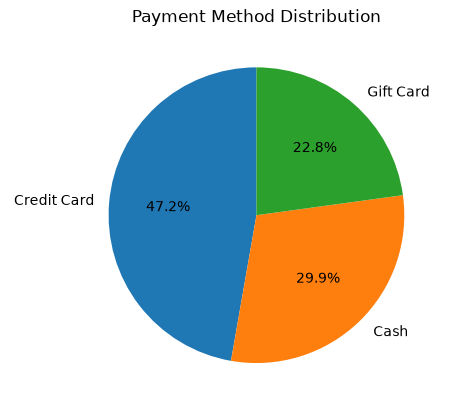

In [34]:
df['Payment Method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')
plt.title('Payment Method Distribution')
plt.show()

### *Most Selliing Products*
- By Quantity
- By Revenue

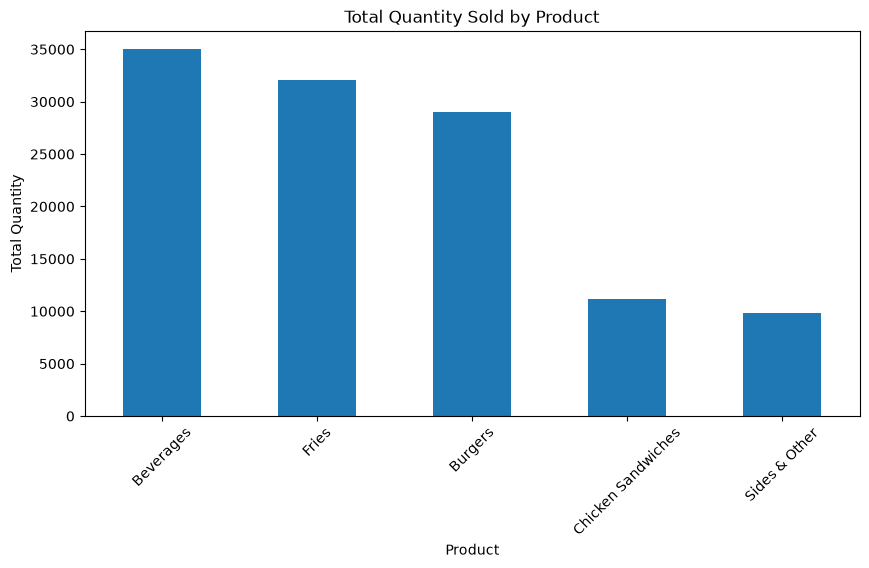

In [37]:
df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.xlabel('Product')
plt.ylabel('Total Quantity')
plt.title('Total Quantity Sold by Product')
plt.xticks(rotation=45)
plt.show()

In [38]:
df['Revenue'] = df['Quantity'] * df['Price']

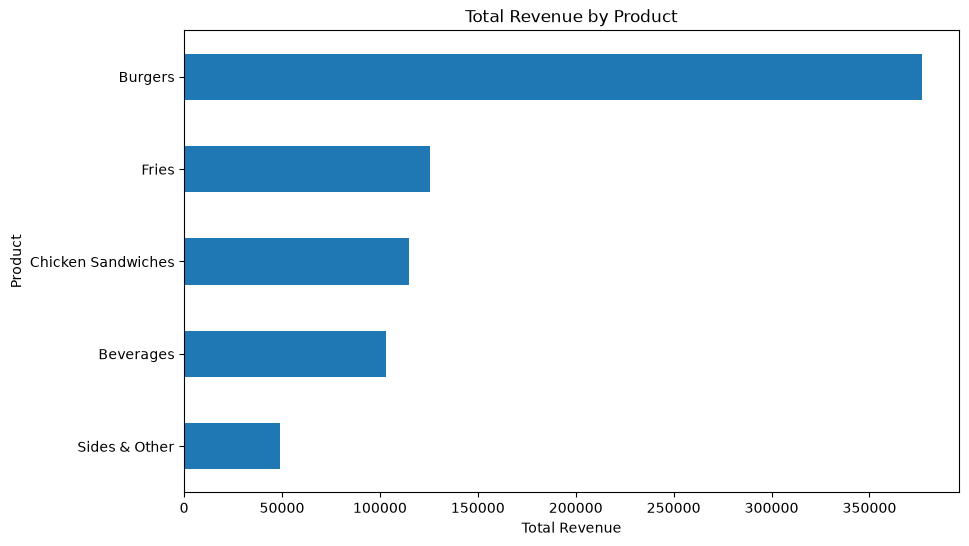

In [41]:
df.groupby('Product')['Revenue'].sum().sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.title('Total Revenue by Product')
plt.show()

### *Top-Performing City by Revenue*

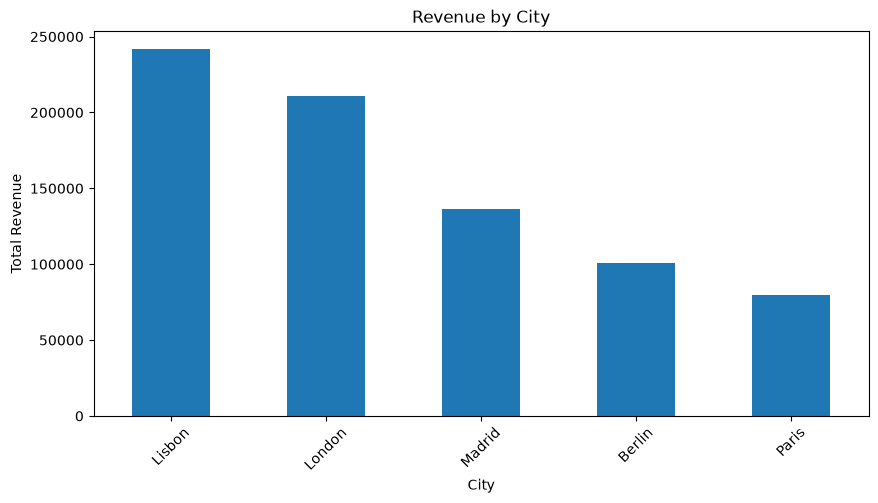

In [43]:
revenue_city = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

revenue_city.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.title('Revenue by City')
plt.xticks(rotation=45)
plt.show()

### *Average Revenue*

In [44]:
df['Revenue'].mean()

np.float64(3028.737952755905)

### *Average Revenue of November and December*

In [46]:
df['Month'] = df['Date'].dt.month

In [52]:
monthly_revenue = df.groupby('Month')['Revenue'].mean()
monthly_revenue

Month
11    2938.186903
12    3101.307234
Name: Revenue, dtype: Float64

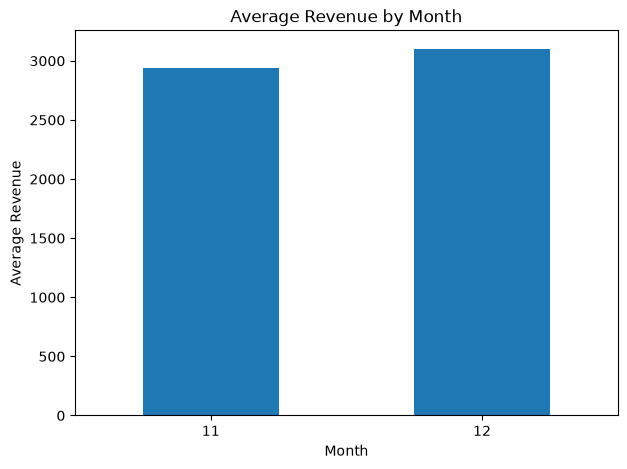

In [53]:
monthly_revenue.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.title('Average Revenue by Month')
plt.xticks(rotation=0)
plt.show()

### *Standard Deviation of Revenue and Quantity*

In [56]:
df['Revenue'].std()

np.float64(2419.9325462715055)

In [57]:
df['Quantity'].std()

np.float64(214.9794309636385)

### *Variance of Revenue and Quantity*

In [58]:
df['Revenue'].var()

np.float64(5856073.528504091)

In [59]:
df['Quantity'].var()

np.float64(46216.15573744981)

### *Average Quantity Sold & Average Revenue for each Product*

In [61]:
df.groupby('Product').agg({'Quantity':'mean','Revenue':'mean'}).round(2)

,Quantity,Revenue
Product,,
Beverages,699.76,2064.29
Burgers,558.04,7248.92
Chicken Sandwiches,214.1,2204.09
Fries,627.9,2463.27
Sides & Other,200.0,998.0
